# Conflict-vs-PSE exploratory plots with free psychometric mu, sigma, and lambda

This companion to `plotConflictvsPSE.ipynb` uses the same free per-condition psychometric parameterization for behavior and model simulations.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from plot_style import (
    setup_style,
    FONT_SIZE_LABEL,
    FONT_SIZE_TITLE,
    FONT_SIZE_LEGEND,
)
from free_psychometric_refits import (
    DEFAULT_MAIN_MODELS,
    DEFAULT_ALL_MODELS,
    collect_free_fits,
    aggregate_free_fits,
    value_label,
)

setup_style()
FONT = FONT_SIZE_LABEL
LINE_WIDTH_DATA = 2.8
LINE_WIDTH_MODEL = 2.4
LINE_WIDTH_AUX = 1.2


In [12]:
PF_MODE = 'lognormal'  # 'lognormal' or 'normal'
FORCE_REFIT = False     # True recomputes and overwrites the free-fit JSON cache

PIDS = ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
MAIN_MODELS = DEFAULT_MAIN_MODELS

# Prefer the LapseFree simulations where available; fall back to LapseFix.
MODEL_VARIANTS = ['LapseFree_sharedPrior', 'LapseFix_sharedPrior', 'LapseFree_contextualPrior']

DATA_COLOR = {0.1: '#d62728', 1.2: '#1f77b4'}
MODEL_STYLE = {
    'lognorm':           dict(label='Causal inference', color='#600c70', ls='-',  marker='o'),
    'fusionOnlyLogNorm': dict(label='Forced fusion',    color='#2ca02c', ls='--', marker='s'),
    'switchingFree':     dict(label='Cue switching',    color='#080529', ls=':',  marker='^'),
}


In [13]:
data_pp, model_pp, missing = collect_free_fits(
    PIDS,
    model_names=MAIN_MODELS,
    pf_mode=PF_MODE,
    force=FORCE_REFIT,
    variants=MODEL_VARIANTS,
)

print(f'Data rows:  {len(data_pp)}')
print(f'Model rows: {len(model_pp)}')
if missing:
    print('Missing simulated CSVs:')
    for pid, model in missing:
        print(f'  {pid}/{model}')

print('\nData sample:')
display(data_pp.head())
print('\nModel sample:')
display(model_pp.head())


Data rows:  154
Model rows: 462

Data sample:


,pid,audioNoise,conflict,conflict_ms,n_trials,mu,sigma,lambda_,nll,success,mu_shift_s,mu_shift_ms,sigma_plot
0,as,0.1,-0.25,-250,155,-0.071989,0.350865,0.0,69.320984,True,-0.034729,-34.729222,0.350865
1,as,0.1,-0.17,-170,164,-0.042469,0.358352,0.0,77.655886,True,-0.020790,-20.789825,0.358352
2,as,0.1,-0.08,-80,142,0.023642,0.275329,0.0,55.970283,True,0.011962,11.961819,0.275329
3,as,0.1,0.00,0,146,-0.040905,0.346234,0.0,64.932543,True,-0.020040,-20.039912,0.346234
4,as,0.1,0.08,80,153,0.021254,0.303179,0.0,59.628045,True,0.010741,10.740912,0.303179



Model sample:


,pid,model,audioNoise,conflict,conflict_ms,n_trials,mu,sigma,lambda_,nll,success,mu_shift_s,mu_shift_ms,sigma_plot
0,as,lognorm,0.1,-0.25,-250,4650,-0.076120,0.297917,0.037353,1984.051760,True,-0.036648,-36.647700,0.297917
1,as,lognorm,0.1,-0.17,-170,4920,-0.050702,0.296650,0.052827,2232.093371,True,-0.024719,-24.719033,0.296650
2,as,lognorm,0.1,-0.08,-80,4260,-0.017537,0.293038,0.081517,1985.477509,True,-0.008692,-8.691921,0.293038
3,as,lognorm,0.1,0.00,0,4380,-0.004671,0.306188,0.029689,1910.528137,True,-0.002330,-2.330065,0.306188
4,as,lognorm,0.1,0.08,80,4590,0.033386,0.268285,0.033229,1776.738938,True,0.016975,16.974541,0.268285


In [14]:
def make_aggregates(value_col='mu_shift_s'):
    data_agg = aggregate_free_fits(data_pp, value_col=value_col)
    model_agg = aggregate_free_fits(model_pp, value_col=value_col)
    return data_agg, model_agg


def _scale_for_value(value_col):
    return 1000.0 if value_col == 'mu_shift_s' else 1.0


def plot_grouped_free(value_col='mu_shift_s', save_prefix=None):
    data_agg, model_agg = make_aggregates(value_col)
    scale = _scale_for_value(value_col)
    y_label = value_label(value_col, pf_mode=PF_MODE)

    audio_levels = sorted(data_agg['audioNoise'].unique())
    fig, axes = plt.subplots(1, len(audio_levels), figsize=(14, 6.5), sharey=False)
    if len(audio_levels) == 1:
        axes = [axes]

    handles = []
    labels = []
    panel_titles = ['A', 'B']

    for idx, (ax, noise) in enumerate(zip(axes, audio_levels)):
        d = data_agg[data_agg['audioNoise'] == noise].sort_values('conflict')
        x = d['conflict'].to_numpy(float) * 1000
        y = d['mean'].to_numpy(float) * scale
        yerr = d['sem'].to_numpy(float) * scale
        ax.errorbar(
            x, y, yerr=yerr, fmt='o-', color=DATA_COLOR.get(noise, 'black'),
            capsize=5, linewidth=LINE_WIDTH_DATA, markersize=8, zorder=5,
            markeredgecolor='white', markeredgewidth=1.0,
        )
        if idx == 0:
            handles.append(Line2D([0], [0], color=DATA_COLOR.get(noise, 'black'), marker='o', lw=LINE_WIDTH_DATA))
            labels.append('Data')

        for model_name in MAIN_MODELS:
            m = model_agg[(model_agg['audioNoise'] == noise) & (model_agg['model'] == model_name)].sort_values('conflict')
            if m.empty:
                continue
            style = MODEL_STYLE.get(model_name, dict(label=model_name, color='gray', ls='-', marker='o'))
            xm = m['conflict'].to_numpy(float) * 1000
            ym = m['mean'].to_numpy(float) * scale
            merr = m['sem'].to_numpy(float) * scale
            ax.errorbar(
                xm, ym, yerr=merr, color=style['color'], linestyle=style['ls'],
                marker=style['marker'], capsize=3, linewidth=LINE_WIDTH_MODEL, markersize=6,
                markerfacecolor=style['color'], markeredgecolor='white', markeredgewidth=0.8,
            )
            if idx == 0:
                handles.append(Line2D([0], [0], color=style['color'], ls=style['ls'], marker=style['marker'], lw=LINE_WIDTH_MODEL))
                labels.append(style['label'])

        ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.65)
        ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.65)
        ax.margins(y=0.18)
        ax.set_title(panel_titles[idx], loc='left', pad=10)
        ax.set_xlabel('Cue conflict (ms)')
        ax.tick_params(axis='x', rotation=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel(y_label)
    handles.append(Line2D([], [], color='none'))
    labels.append(f'mean +/- SEM (n={len(PIDS)})')
    fig.legend(handles, labels, loc='lower center',
               bbox_to_anchor=(0.5, -0.03), ncol=5, frameon=True, edgecolor='black')
    plt.tight_layout(rect=(0, 0.08, 1, 1))

    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.svg', bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf/.svg')
    plt.show()
    return data_agg, model_agg


Saved aggregated_mu_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


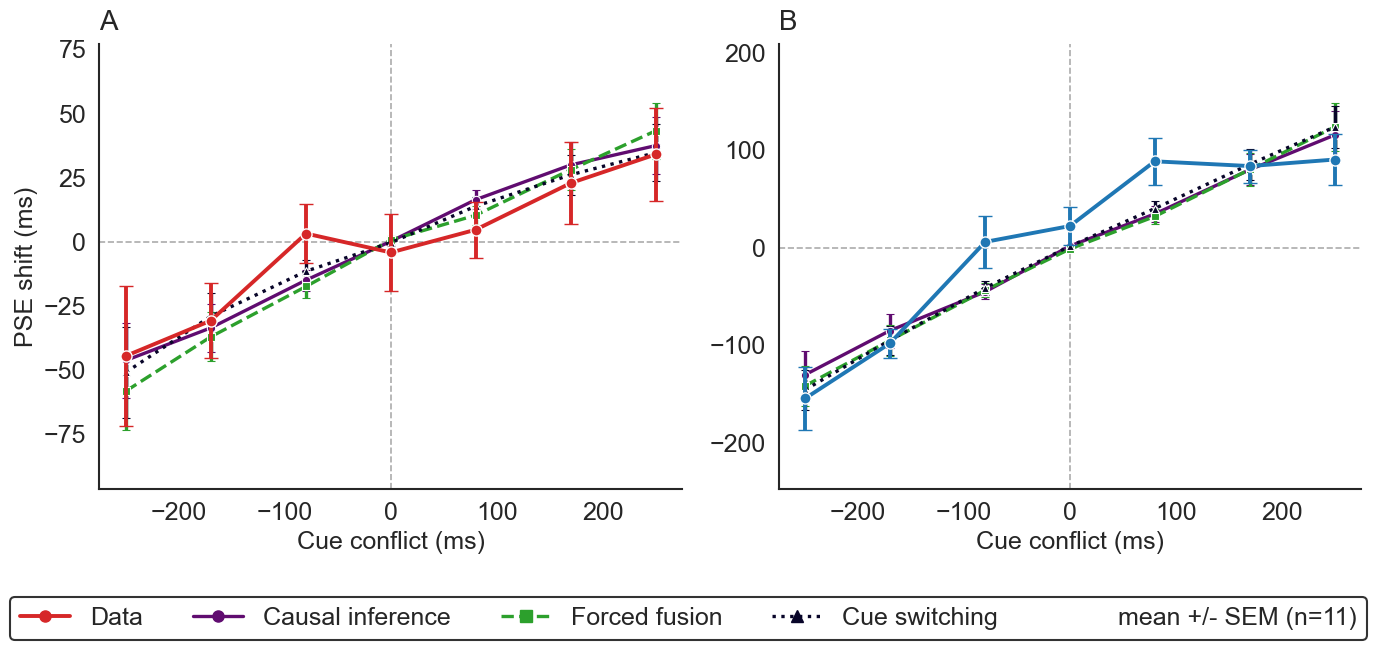

In [15]:
mu_data_agg, mu_model_agg = plot_grouped_free(
    'mu_shift_s',
    save_prefix='aggregated_mu_vs_models_freeMuSigmaLambda_sem',
)


Saved aggregated_sigma_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


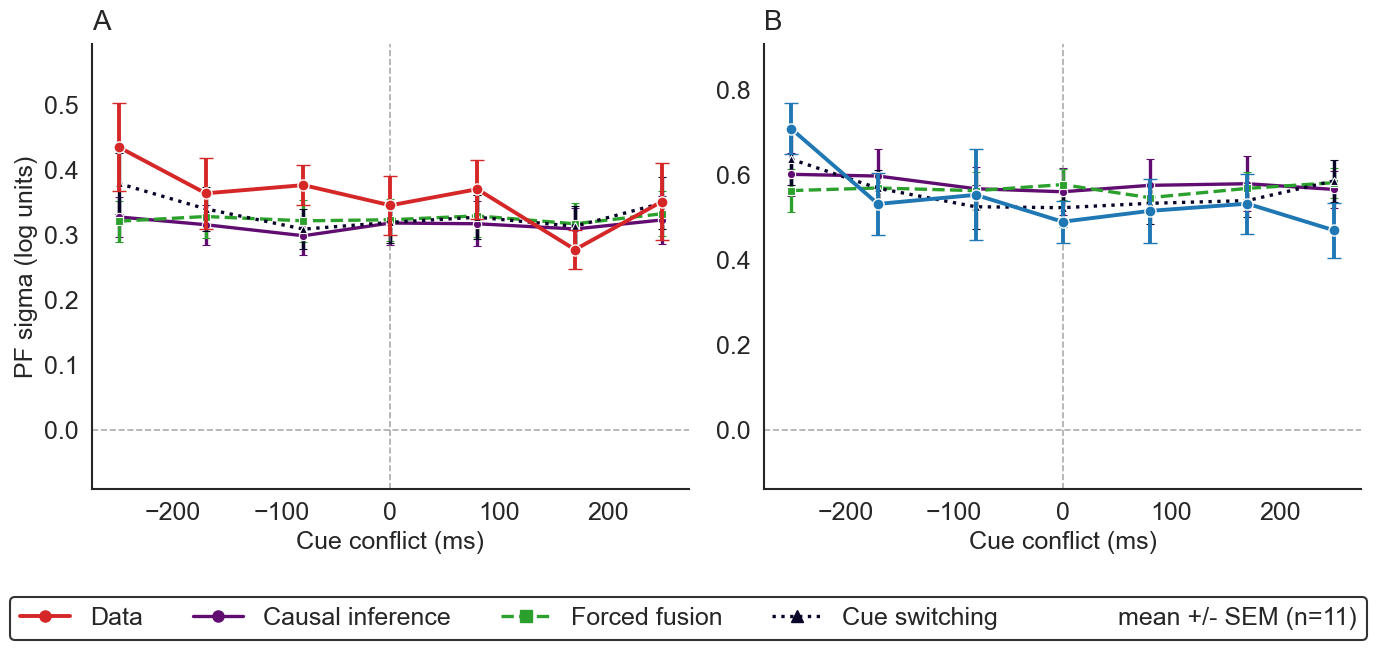

Saved aggregated_lambda_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


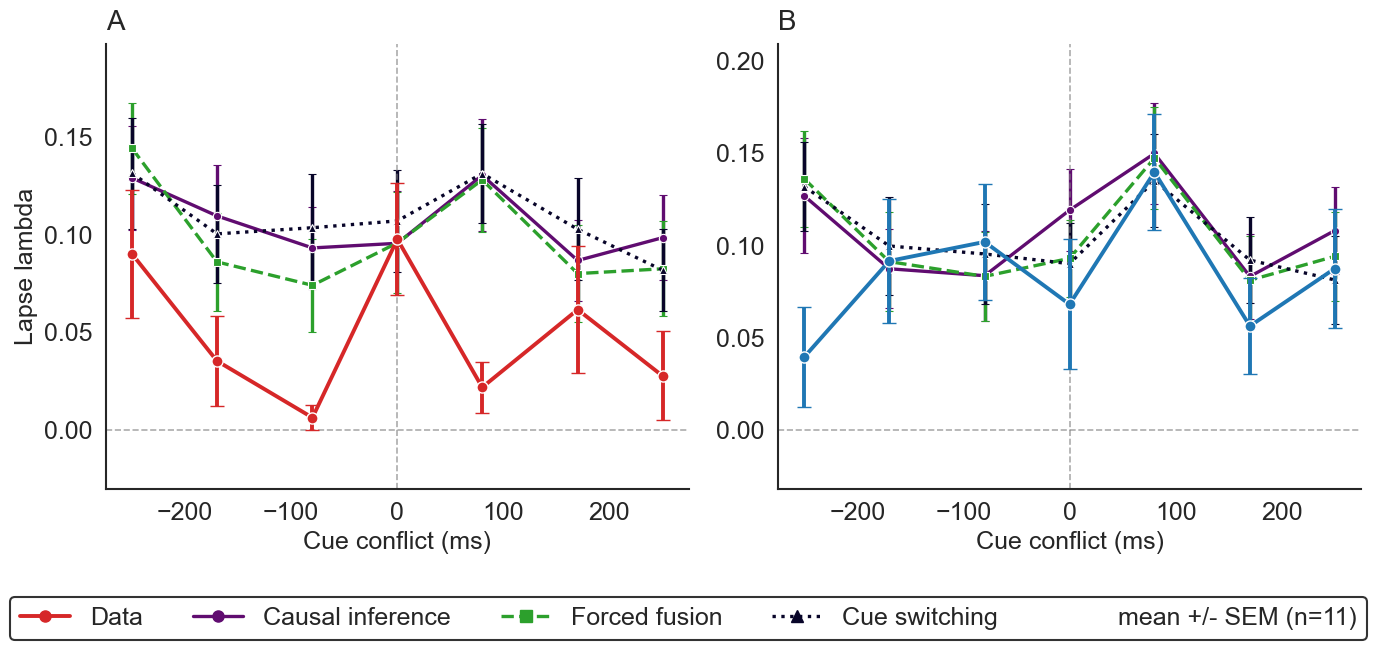

In [16]:
sigma_data_agg, sigma_model_agg = plot_grouped_free(
    'sigma_plot',
    save_prefix='aggregated_sigma_vs_models_freeMuSigmaLambda_sem',
)

lambda_data_agg, lambda_model_agg = plot_grouped_free(
    'lambda_',
    save_prefix='aggregated_lambda_vs_models_freeMuSigmaLambda_sem',
)


Saved per_participant_mu_freeMuSigmaLambda.png/.pdf


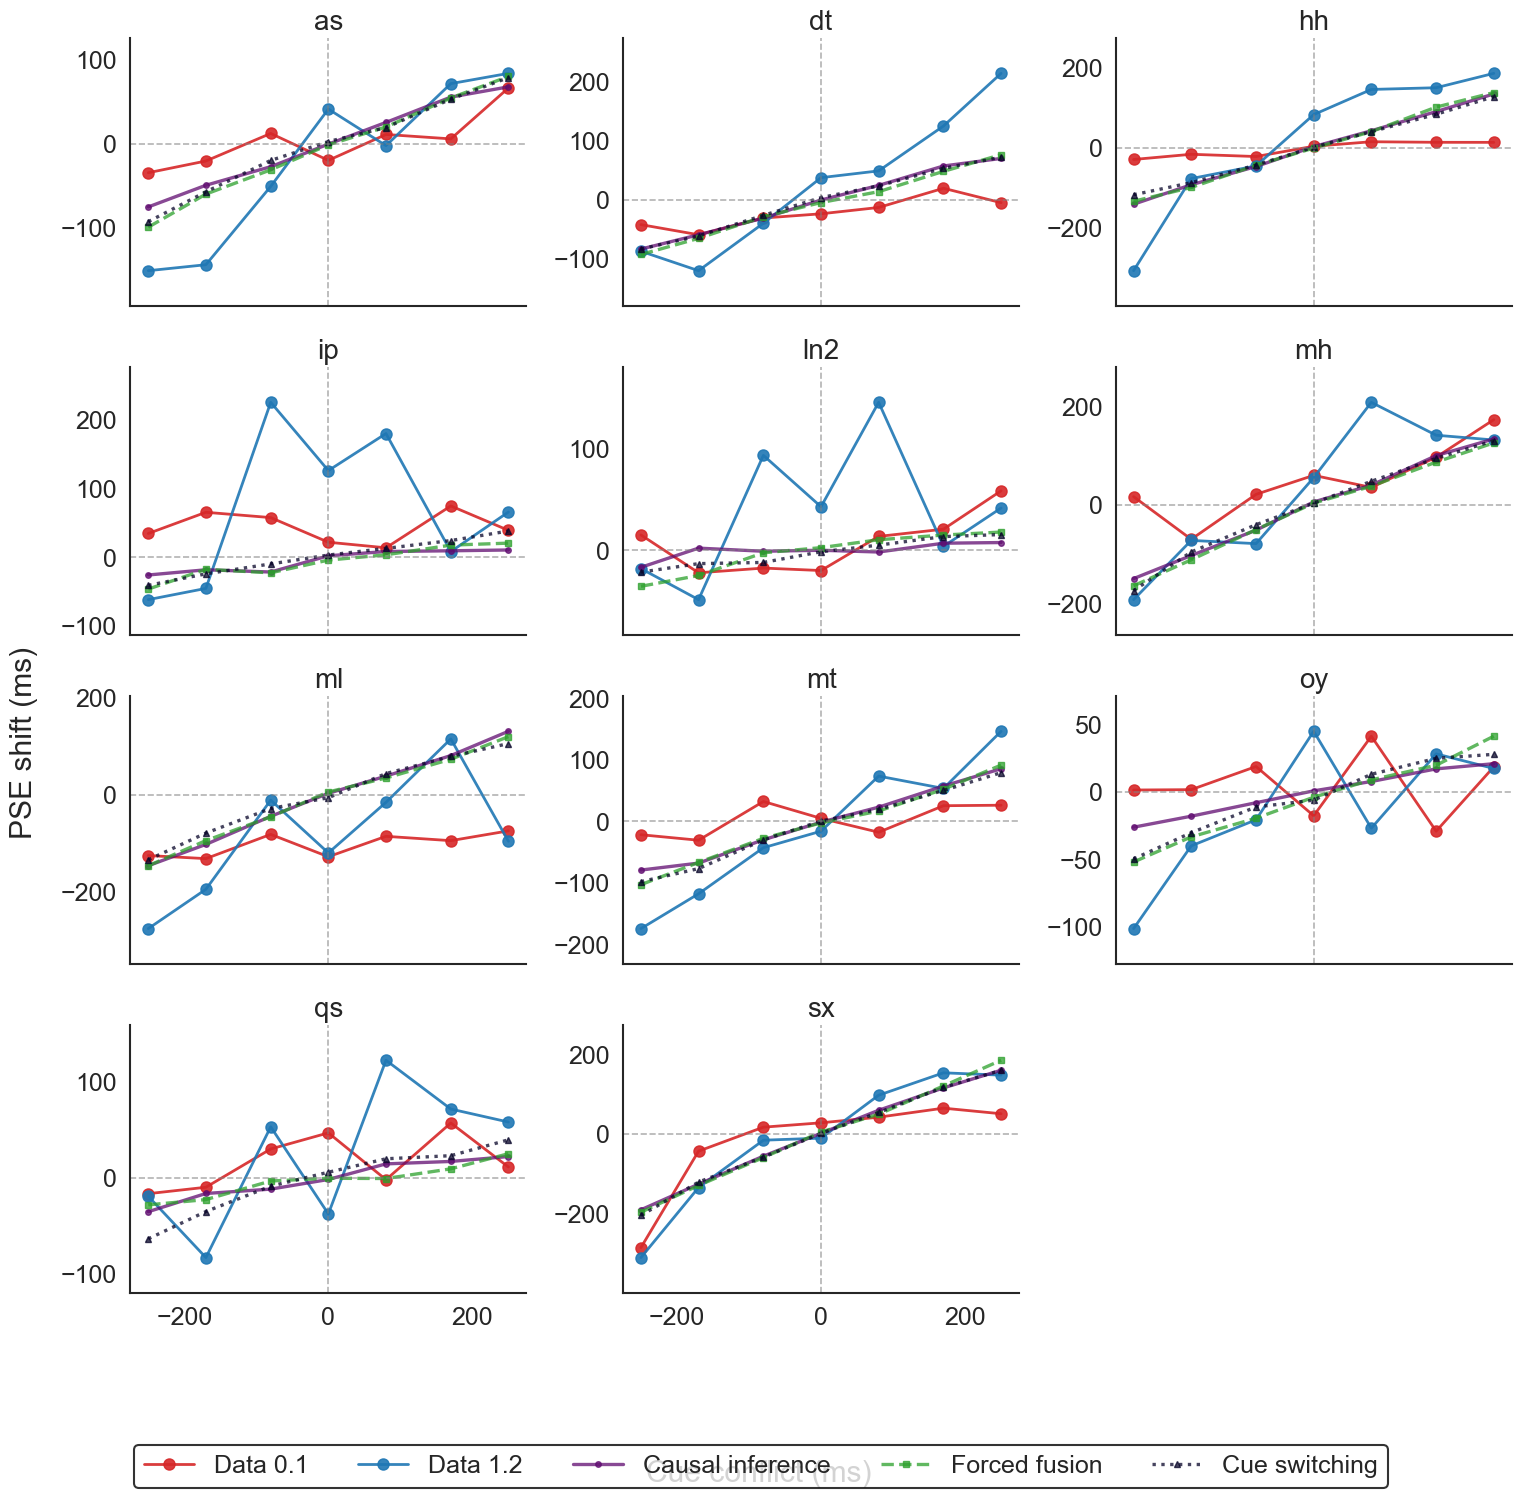

In [17]:
def plot_per_participant_free(value_col='mu_shift_s', models=MAIN_MODELS, save_prefix=None):
    scale = _scale_for_value(value_col)
    y_label = value_label(value_col, pf_mode=PF_MODE)
    n_cols = 3
    n_rows = int(np.ceil(len(PIDS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.8 * n_rows), sharex=True, sharey=False)
    axes = np.asarray(axes).reshape(-1)

    for ax, pid in zip(axes, PIDS):
        dp = data_pp[data_pp['pid'] == pid]
        for noise in sorted(dp['audioNoise'].unique()):
            d = dp[dp['audioNoise'] == noise].sort_values('conflict')
            ax.plot(d['conflict'] * 1000, d[value_col] * scale, 'o-',
                    color=DATA_COLOR.get(noise, 'black'), alpha=0.9,
                    label=f'Data {noise}' if pid == PIDS[0] else None)

        for model_name in models:
            mp = model_pp[(model_pp['pid'] == pid) & (model_pp['model'] == model_name)]
            if mp.empty:
                continue
            style = MODEL_STYLE.get(model_name, dict(label=model_name, color='gray', ls='-', marker='o'))
            collapsed = mp.groupby('conflict')[value_col].mean().reset_index().sort_values('conflict')
            ax.plot(collapsed['conflict'] * 1000, collapsed[value_col] * scale,
                    linestyle=style['ls'], marker=style['marker'], color=style['color'],
                    alpha=0.75, linewidth=LINE_WIDTH_MODEL, markersize=4,
                    label=style['label'] if pid == PIDS[0] else None)

        ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
        ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
        ax.margins(y=0.18)
        ax.set_title(pid)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes[len(PIDS):]:
        ax.axis('off')

    fig.supxlabel('Cue conflict (ms)')
    fig.supylabel(y_label)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, frameon=True, edgecolor='black')
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf')
    plt.show()

plot_per_participant_free('mu_shift_s', save_prefix='per_participant_mu_freeMuSigmaLambda')


## Optional: all simulated model families

This section fits every model family available in `simulated_data/`. It is slower than the three-model section but uses the same cache, so repeated runs are cheap unless `FORCE_REFIT=True`.

In [18]:
ALL_MODELS = DEFAULT_ALL_MODELS
all_data_pp, all_model_pp, all_missing = collect_free_fits(
    PIDS,
    model_names=ALL_MODELS,
    pf_mode=PF_MODE,
    force=FORCE_REFIT,
    variants=MODEL_VARIANTS,
)

print(f'All-model rows: {len(all_model_pp)}')
if all_missing:
    print('Missing all-model simulations:')
    for pid, model in all_missing[:30]:
        print(f'  {pid}/{model}')
    if len(all_missing) > 30:
        print(f'  ... {len(all_missing) - 30} more')


All-model rows: 1694


In [19]:
def plot_all_models_grid(value_col='mu_shift_s', save_prefix='all_models_freeMuSigmaLambda_grid'):
    data_agg = aggregate_free_fits(all_data_pp, value_col=value_col)
    model_agg = aggregate_free_fits(all_model_pp, value_col=value_col)
    scale = _scale_for_value(value_col)
    audio_levels = sorted(data_agg['audioNoise'].unique())
    models = [m for m in ALL_MODELS if m in set(model_agg['model'])]

    fig, axes = plt.subplots(len(models), len(audio_levels), figsize=(12, max(3.0 * len(models), 5)),
                             sharex=True, sharey=False, squeeze=False)
    palette = dict(zip(models, sns.color_palette('tab20', n_colors=len(models))))

    for ri, model_name in enumerate(models):
        for ci, noise in enumerate(audio_levels):
            ax = axes[ri, ci]
            d = data_agg[data_agg['audioNoise'] == noise].sort_values('conflict')
            ax.errorbar(d['conflict'] * 1000, d['mean'] * scale, yerr=d['sem'] * scale,
                        color=DATA_COLOR.get(noise, 'black'), fmt='o', capsize=3,
                        linewidth=LINE_WIDTH_DATA, alpha=0.8)
            m = model_agg[(model_agg['audioNoise'] == noise) & (model_agg['model'] == model_name)].sort_values('conflict')
            if not m.empty:
                ax.errorbar(m['conflict'] * 1000, m['mean'] * scale, yerr=m['sem'] * scale,
                            color=palette[model_name], fmt='o-', capsize=3,
                            linewidth=LINE_WIDTH_MODEL)
            ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
            ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
            ax.margins(y=0.18)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if ri == 0:
                ax.set_title('Low auditory noise' if ci == 0 else 'High auditory noise', fontsize=FONT - 2)
            if ci == 0:
                ax.set_ylabel(model_name, fontsize=FONT - 5)

    fig.supxlabel('Cue conflict (ms)')
    fig.supylabel(value_label(value_col, pf_mode=PF_MODE))
    plt.tight_layout(rect=(0.05, 0.04, 1, 1))
    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.svg', bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf/.svg')
    plt.show()

#plot_all_models_grid('mu_shift_s', save_prefix='all_models_mu_freeMuSigmaLambda_grid')


# Model comparison table (ΔAIC)

Three-model ΔAIC comparison appended here just like in `modelComparisonTable_threeModels.ipynb`.
Loads the per-participant JSON fits for the three target models from two sources —
`unimodalSigma_modelFits` (sensory noise fixed from unimodal fits) and `model_fits`
(sensory noise fit freely) — and renders the per-participant ΔAIC heatmap vs. the
Forced-fusion baseline, with the summed ΔAIC across participants.

In [20]:
import os
import json
import glob

# Map raw model tag -> display name. Only the three target models.
TARGET_MODELS = {
    'lognorm_sharedPrior': 'Causal-inference averaging',
    'fusionOnlyLogNorm_sharedPrior': 'Forced fusion',
    'switchingFree_sharedPrior': 'Probabilistic cue switching',
}

# Order used in plots / tables
MODEL_ORDER = [
    'Forced fusion',
    'Causal-inference averaging',
    'Probabilistic cue switching',
]

# Baseline for delta criteria in the comparison table.
BASE_MODEL = 'Forced fusion'

FONT_SIZE = 18

FIT_SOURCE_CONFIGS = {
    'free_sigma': {
        'glob_pattern': 'model_fits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': ('LapseFree',),
    },
    'unimodal_sigma': {
        'glob_pattern': 'unimodalSigma_modelFits/**/*.json',
        'exclude_filename_substrings': ('all', 'lnd1', 'ln1', 'loglinear'),
        'exclude_tags': (),
    },
}


def load_target_model_results(source):
    """Load JSON fits and keep only rows for the three target models."""
    config = FIT_SOURCE_CONFIGS[source]
    json_files = sorted(glob.glob(config['glob_pattern'], recursive=True))

    results = []
    for file_path in json_files:
        filename = os.path.basename(file_path)
        filename_lower = filename.lower()

        if any(s in filename_lower for s in config['exclude_filename_substrings']):
            continue
        if config['exclude_tags'] and any(tag in filename for tag in config['exclude_tags']):
            continue

        parts = filename.replace('.json', '').split('_')
        # convention: <pid>_<modelBase>_<lapseTag>_<priorTag>_fit.json
        raw_model_tag = f"{parts[1]}_{parts[3]}"
        if raw_model_tag not in TARGET_MODELS:
            continue

        with open(file_path, 'r') as f:
            result = json.load(f)

        result['participantID'] = result.get('participantID', parts[0]).lower()
        result['modelType'] = TARGET_MODELS[raw_model_tag]
        result['fit_source'] = source
        result['fit_file'] = file_path
        results.append(result)

    df = pd.DataFrame(results)
    if df.empty:
        return df

    df['participantID'] = df['participantID'].astype(str).str.lower()
    df['nParameters'] = df['fittedParams'].apply(len)
    df['AIC_recalculated'] = 2 * df['nParameters'] - 2 * df['logLikelihood']
    df['AIC'] = df['AIC_recalculated']
    return df


df_free = load_target_model_results('free_sigma')
df_unimodal = load_target_model_results('unimodal_sigma')

print(f"free_sigma:     {len(df_free)} rows, participants={sorted(df_free['participantID'].unique())}")
print(f"unimodal_sigma: {len(df_unimodal)} rows, participants={sorted(df_unimodal['participantID'].unique())}")
print(f"Models present: {sorted(df_free['modelType'].unique())}")

free_sigma:     33 rows, participants=['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
unimodal_sigma: 33 rows, participants=['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
Models present: ['Causal-inference averaging', 'Forced fusion', 'Probabilistic cue switching']


ΔAIC vs. baseline (free sensory noise):
modelType      Forced fusion  Causal-inference averaging  Probabilistic cue switching
participantID                                                                        
as                       0.0                         2.3                          4.7
dt                       0.0                         1.4                          1.5
hh                       0.0                        -2.1                          3.0
ip                       0.0                        -1.6                         -4.5
ln2                      0.0                        -1.6                          7.2
mh                       0.0                        -5.7                         -2.5
ml                       0.0                         1.4                         -4.7
mt                       0.0                        -5.8                         -8.3
oy                       0.0                        -3.1                         -6.0
qs            

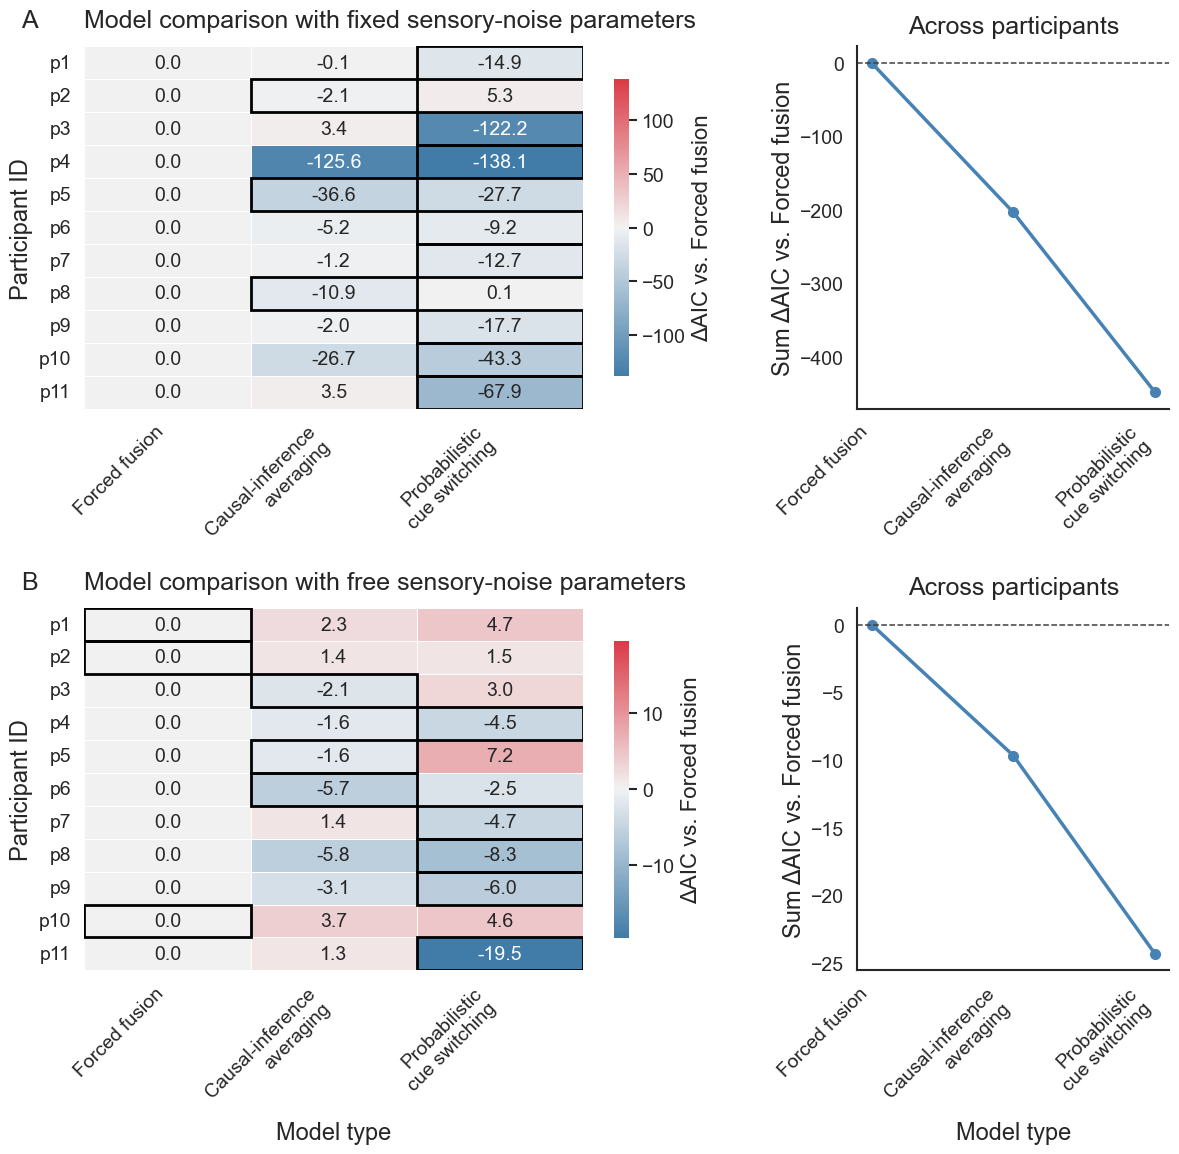

In [21]:
def wrap_label(text, max_chars=15):
    words = text.split()
    if not words:
        return text
    lines = [words[0]]
    for word in words[1:]:
        candidate = f"{lines[-1]} {word}"
        if len(candidate) <= max_chars:
            lines[-1] = candidate
        else:
            lines.append(word)
    return "\n".join(lines)


def add_base_model_deltas(df_results, base_model=BASE_MODEL):
    df = df_results.copy()
    base = df.loc[df['modelType'] == base_model, ['participantID', 'AIC', 'BIC']].rename(
        columns={'AIC': 'base_AIC', 'BIC': 'base_BIC'}
    )
    missing_base = sorted(set(df['participantID']) - set(base['participantID']))
    if missing_base:
        raise ValueError(f"Missing {base_model!r} rows for participants: {missing_base}")

    df = df.merge(base, on='participantID', how='left', validate='many_to_one')
    df['deltaAIC'] = df['AIC'] - df['base_AIC']
    df['deltaBIC'] = df['BIC'] - df['base_BIC']
    return df


def delta_aic_table(df_results, base_model=BASE_MODEL):
    df = add_base_model_deltas(df_results, base_model=base_model)
    table = df.pivot(index='participantID', columns='modelType', values='deltaAIC')
    table = table.reindex(index=sorted(table.index), columns=MODEL_ORDER)
    return table


def sum_delta_aic(df_results, base_model=BASE_MODEL):
    summary = delta_aic_table(df_results, base_model=base_model).sum(axis=0)
    return summary.rename('sum_deltaAIC').to_frame()


def draw_delta_aic_heatmap_row(fig, axes, delta_table, panel_label, panel_title,
                               base_model=BASE_MODEL, show_xlabels=True):
    ax_heat, ax_sum = axes
    delta_table = delta_table.reindex(columns=[m for m in MODEL_ORDER if m in delta_table.columns])

    finite = delta_table.to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    absmax = max(float(np.abs(finite).max()) if finite.size else 1.0, 1.0)

    heatmap = sns.heatmap(
        delta_table,
        annot=True,
        fmt='.1f',
        cmap=sns.diverging_palette(240, 10, as_cmap=True),
        center=0,
        vmin=-absmax,
        vmax=absmax,
        linewidths=0.5,
        linecolor='white',
        ax=ax_heat,
        cbar=True,
        cbar_kws={'label': f'ΔAIC vs. {base_model}', 'shrink': 0.82},
        annot_kws={'fontsize': FONT_SIZE - 4},
    )
    cbar = heatmap.collections[0].colorbar
    cbar.set_label(f'ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 2)
    cbar.ax.tick_params(labelsize=FONT_SIZE - 4)

    ax_heat.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1)
    ax_heat.set_ylabel('Participant ID', fontsize=FONT_SIZE - 1)
    ax_heat.set_xticklabels([wrap_label(tick.get_text()) for tick in ax_heat.get_xticklabels()],
                            rotation=45, ha='right', fontsize=FONT_SIZE - 4)
    ax_heat.set_yticklabels([f'p{i}' for i, _ in enumerate(delta_table.index, start=1)],
                            rotation=0, fontsize=FONT_SIZE - 4)

    # Box the best-fitting model (lowest AIC, i.e. smallest ΔAIC) for each participant.
    values = delta_table.to_numpy(dtype=float)
    for row_idx in range(values.shape[0]):
        best_col = int(np.nanargmin(values[row_idx]))
        ax_heat.add_patch(plt.Rectangle((best_col, row_idx), 1, 1, fill=False,
                                        edgecolor='black', lw=2.0))

    model_sums = delta_table.sum(axis=0).reindex(delta_table.columns)
    ax_sum.plot(range(len(model_sums)), model_sums.values, marker='o', linestyle='-',
                linewidth=2.5, markersize=7, color='steelblue')
    ax_sum.axhline(0, color='0.25', linewidth=1.1, linestyle='--')
    ax_sum.set_xticks(range(len(model_sums)))
    ax_sum.set_xticklabels([wrap_label(model) for model in model_sums.index],
                           rotation=45, ha='right', fontsize=FONT_SIZE - 4)
    ax_sum.set_xlabel('Model type' if show_xlabels else '', fontsize=FONT_SIZE - 1)
    ax_sum.set_ylabel(f'Sum ΔAIC vs. {base_model}', fontsize=FONT_SIZE - 1)
    ax_sum.set_title('Across participants', fontsize=FONT_SIZE, pad=10)
    ax_sum.tick_params(axis='y', labelsize=FONT_SIZE - 4)
    ax_sum.spines['top'].set_visible(False)
    ax_sum.spines['right'].set_visible(False)

    bbox = ax_heat.get_position()
    title_y = bbox.y1 + 0.012
    fig.text(bbox.x0 - 0.045, title_y, panel_label, fontsize=FONT_SIZE, ha='left', va='bottom')
    fig.text(bbox.x0, title_y, panel_title, fontsize=FONT_SIZE, ha='left', va='bottom')


def plot_three_model_delta_aic_heatmap(base_model=BASE_MODEL,
                                       save_path='modelComparison_threeModels_heatmap_freeMuSigmaLambda.pdf'):
    specs = [
        {'panel_label': 'A', 'title': 'Model comparison with fixed sensory-noise parameters',
         'table': delta_aic_table(df_unimodal, base_model=base_model)},
        {'panel_label': 'B', 'title': 'Model comparison with free sensory-noise parameters',
         'table': delta_aic_table(df_free, base_model=base_model)},
    ]

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 12),
        gridspec_kw={'width_ratios': [2.4, 1.2], 'hspace': 0.55, 'wspace': 0.32},
    )
    fig.patch.set_facecolor('white')

    for row_idx, spec in enumerate(specs):
        draw_delta_aic_heatmap_row(
            fig, axes[row_idx], spec['table'],
            panel_label=spec['panel_label'], panel_title=spec['title'],
            base_model=base_model, show_xlabels=(row_idx == len(specs) - 1),
        )

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()
    return specs


free_delta_table = delta_aic_table(df_free)
uni_delta_table = delta_aic_table(df_unimodal)
free_sum_delta_aic = sum_delta_aic(df_free)
uni_sum_delta_aic = sum_delta_aic(df_unimodal)

print('ΔAIC vs. baseline (free sensory noise):')
print(free_delta_table.round(1).to_string())
print('\nSum ΔAIC across participants (free sensory noise):')
print(free_sum_delta_aic.round(1).to_string())
print('\nΔAIC vs. baseline (fixed sensory noise):')
print(uni_delta_table.round(1).to_string())
print('\nSum ΔAIC across participants (fixed sensory noise):')
print(uni_sum_delta_aic.round(1).to_string())

comparison_heatmap_datasets = plot_three_model_delta_aic_heatmap()

# Parameter recovery (from the empirical model recovery)

Parameter recovery extracted from the **empirical** model-recovery run in
`model_recovery_results/` — i.e. data generated from each participant's *empirical*
fitted parameters (`true_params`) and re-fit. For each of the three main models we
pair the generating `true_params` with the recovered `fittedParams` of the **same**
model, pooling all participants × iterations (11 × 5 = 55 points/parameter), and plot
true vs. recovered per parameter with the identity line and r / RMSE.

Parameter layout is the LapseFree (`sharedLambda=False`) ordering used by these fits:
- Causal inference (`lognorm`, 7): `[λ, σa1, σv, p_c, σa2, λ2, λ3]`
- Forced fusion (`fusionOnlyLogNorm`, 6): `[λ, σa1, σv, σa2, λ2, λ3]`
- Cue switching (`switchingFree`, 8): `[λ, σa1, σv, p_sw1, σa2, λ2, λ3, p_sw2]`

Saved param_recovery_empiricalModelRecovery_lognorm.pdf/.svg/.png


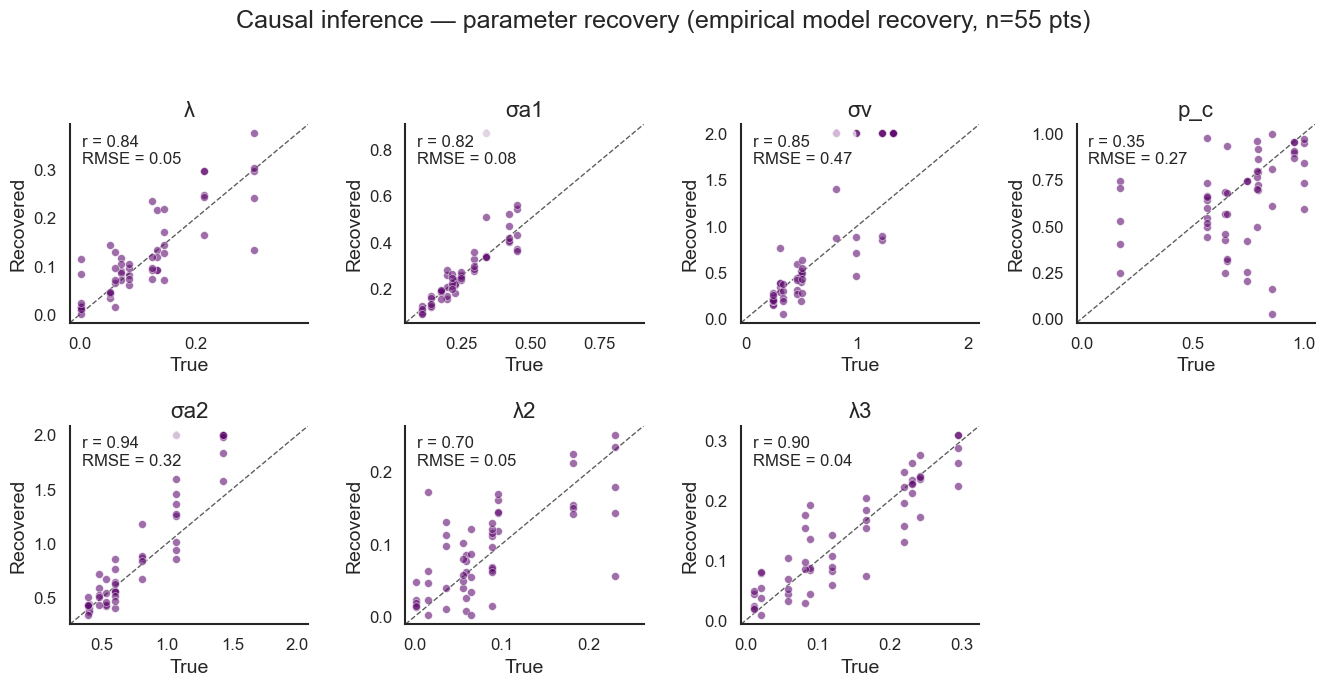

Saved param_recovery_empiricalModelRecovery_fusionOnlyLogNorm.pdf/.svg/.png


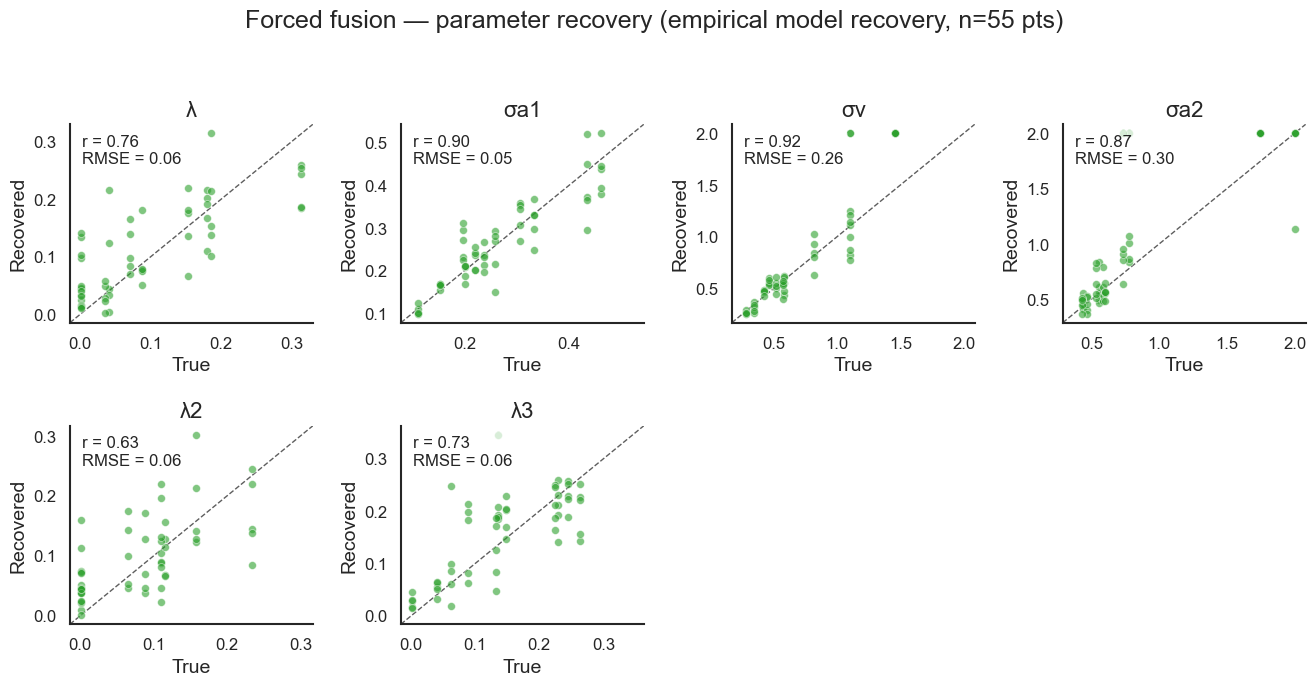

Saved param_recovery_empiricalModelRecovery_switchingFree.pdf/.svg/.png


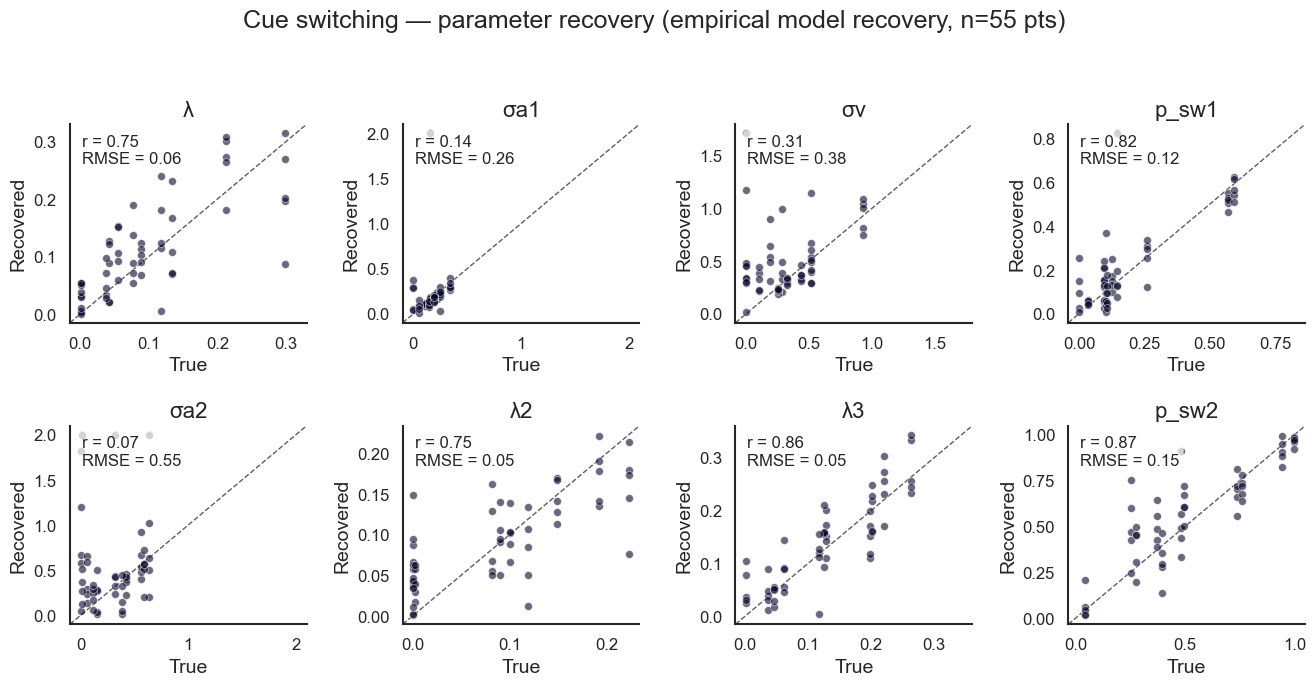

In [22]:
# Empirical model-recovery source and the LapseFree (sharedLambda=False) param layout.
RECOVERY_DIR = 'model_recovery_results'
RECOVERY_MODELS = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree']

RECOVERY_DISPLAY_NAME = {
    'lognorm': 'Causal inference',
    'fusionOnlyLogNorm': 'Forced fusion',
    'switchingFree': 'Cue switching',
}

PARAM_NAMES_RECOVERY = {
    'lognorm':           ['λ', 'σa1', 'σv', 'p_c', 'σa2', 'λ2', 'λ3'],
    'fusionOnlyLogNorm': ['λ', 'σa1', 'σv', 'σa2', 'λ2', 'λ3'],
    'switchingFree':     ['λ', 'σa1', 'σv', 'p_sw1', 'σa2', 'λ2', 'λ3', 'p_sw2'],
}


def load_param_recovery(model, results_dir=RECOVERY_DIR):
    """Pair generating true_params with the same model's recovered fittedParams.

    Returns (true_matrix, recovered_matrix) of shape (n_points, n_params), pooling
    over all participants and recovery iterations in the empirical model recovery.
    """
    files = sorted(glob.glob(os.path.join(results_dir, f'*_{model}_model_recovery.json')))
    true_rows, rec_rows = [], []
    for fp in files:
        with open(fp) as f:
            d = json.load(f)
        if d.get('generating_model') != model:
            continue
        true_vec = np.asarray(d['true_params'], dtype=float)
        for it in d.get('iterations', []):
            fit = it.get('model_fits', {}).get(model)
            if not fit or fit.get('fittedParams') is None:
                continue
            rec_vec = np.asarray(fit['fittedParams'], dtype=float)
            if rec_vec.shape == true_vec.shape:
                true_rows.append(true_vec)
                rec_rows.append(rec_vec)
    return np.asarray(true_rows), np.asarray(rec_rows)


def plot_param_recovery(model, save_prefix=None):
    """True vs. recovered scatter, one subplot per parameter, with identity line + r/RMSE."""
    names = PARAM_NAMES_RECOVERY[model]
    T, R = load_param_recovery(model)
    if T.size == 0:
        print(f'No recovery data for {model}')
        return T, R

    color = MODEL_STYLE.get(model, {}).get('color', 'steelblue')
    n = len(names)
    ncol = min(n, 4)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.4 * nrow))
    axes = np.atleast_1d(axes).reshape(-1)

    for j, name in enumerate(names):
        ax = axes[j]
        x, y = T[:, j], R[:, j]
        ax.scatter(x, y, s=32, color=color, alpha=0.6,
                   edgecolor='white', linewidth=0.5, zorder=3)
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.05 * (hi - lo + 1e-9)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--',
                lw=1.0, alpha=0.7, zorder=2)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)

        r = np.corrcoef(x, y)[0, 1]
        rmse = float(np.sqrt(np.mean((x - y) ** 2)))
        ax.text(0.05, 0.95, f'r = {r:.2f}\nRMSE = {rmse:.2f}', transform=ax.transAxes,
                va='top', ha='left', fontsize=FONT - 6,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.7))
        ax.set_title(name, fontsize=FONT - 2)
        ax.set_xlabel('True', fontsize=FONT - 4)
        ax.set_ylabel('Recovered', fontsize=FONT - 4)
        ax.tick_params(labelsize=FONT - 6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes[n:]:
        ax.axis('off')

    n_points = T.shape[0]
    fig.suptitle(f'{RECOVERY_DISPLAY_NAME[model]} — parameter recovery '
                 f'(empirical model recovery, n={n_points} pts)',
                 fontsize=FONT, y=1.02)
    plt.tight_layout()
    if save_prefix:
        fig.savefig(f'{save_prefix}.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.svg', bbox_inches='tight')
        fig.savefig(f'{save_prefix}.png', dpi=200, bbox_inches='tight')
        print(f'Saved {save_prefix}.pdf/.svg/.png')
    plt.show()
    return T, R


param_recovery_data = {}
for _model in RECOVERY_MODELS:
    param_recovery_data[_model] = plot_param_recovery(
        _model, save_prefix=f'param_recovery_empiricalModelRecovery_{_model}')